In [1]:
import snapatac2 as snap
import numpy as np
import pandas as pd
# Set the environment variable to the desired cache path
import os
os.environ['SNAP_DATA_DIR'] = '/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Snapatac2/IPC'
snap.__version__

'2.6.4'

## data

In [2]:
data = snap.read_dataset("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P2/SnapATAC2/hsc_raw.h5ads")
# data.obs[:].to_pandas()
data

AnnDataSet object with n_obs x n_vars = 109782 x 606219 backed at '/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P2/SnapATAC2/hsc_raw.h5ads'
contains 8 AnnData objects with keys: 'GW7', 'GW12', 'GW6', 'GW9', 'GW10', 'GW16', 'GW17', 'GW20'
    obs: 'sample'
    uns: 'reference_sequences', 'AnnDataSet'
    obsm: 'fragment_paired'

In [3]:
adata = data.to_adata()

In [4]:
data.close()

In [5]:
adata

AnnData object with n_obs × n_vars = 109782 × 606219
    obs: 'sample'
    uns: 'reference_sequences', 'AnnDataSet'
    obsm: 'fragment_paired'

In [6]:
# annotation
anno = pd.read_csv("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Scanpy/IPC/IPC_lineage.csv", index_col=0)
anno

,barcode2,sample2,celltype
AAACAGCCATCGTTCT-1-0,AAACAGCCATCGTTCT-1,GW6,NPC
AAACCGAAGACCATAC-1-0,AAACCGAAGACCATAC-1,GW6,NPC
AAACCGAAGGTCCACA-1-0,AAACCGAAGGTCCACA-1,GW6,NPC
AAACCGAAGTCATGCG-1-0,AAACCGAAGTCATGCG-1,GW6,NPC
AAACCGGCAAATTGCT-1-0,AAACCGGCAAATTGCT-1,GW6,NPC
...,...,...,...
TTTGTGGCAAGTCGCT-1-7,TTTGTGGCAAGTCGCT-1,GW20,IPC
TTTGTGGCACGTAATT-1-7,TTTGTGGCACGTAATT-1,GW20,OPC
TTTGTGGCACTAAATC-1-7,TTTGTGGCACTAAATC-1,GW20,APC
TTTGTGTTCCGCATGA-1-7,TTTGTGTTCCGCATGA-1,GW20,IPC


In [7]:
adata = adata[adata.obs.index.isin(anno.index)]
adata.obs = adata.obs.join(anno)

In [8]:
adata.obs = adata.obs[['sample2', 'barcode2', 'celltype']]

In [9]:
adata.obs['sample2'].value_counts()

sample2
GW16    2807
GW7     2365
GW20    1564
GW17    1485
GW12    1074
GW10     867
GW9      811
GW6      772
Name: count, dtype: int64

# Calculate spectral

In [10]:
snap.pp.select_features(adata, n_features=250000)
snap.tl.spectral(adata)
snap.tl.umap(adata)

2026-03-10 17:42:49 - INFO - Selected 250000 features.
/cluster2/huanglab/jiamao/conda/envs/R-4.3.0/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/cluster2/huanglab/jiamao/conda/envs/R-4.3.0/lib/python3.12/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


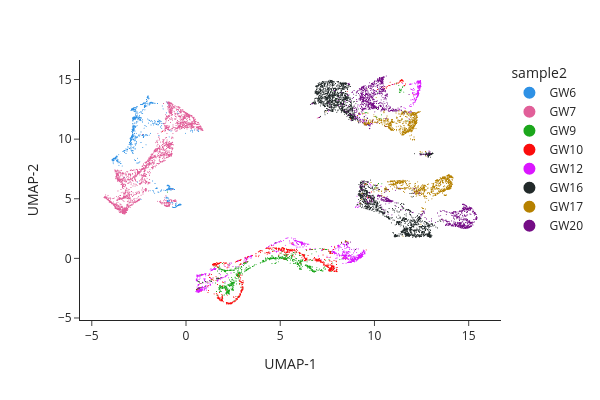

In [11]:
snap.pl.umap(adata, color="sample2", interactive=False)

# Batch correction

In [12]:
%%time
snap.pp.mnc_correct(adata, 
                    batch="sample2")

CPU times: user 11min 13s, sys: 33min 52s, total: 45min 6s
Wall time: 29 s


/cluster2/huanglab/jiamao/conda/envs/R-4.3.0/lib/python3.12/site-packages/umap/umap_.py:1943: UserWarning:

n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.



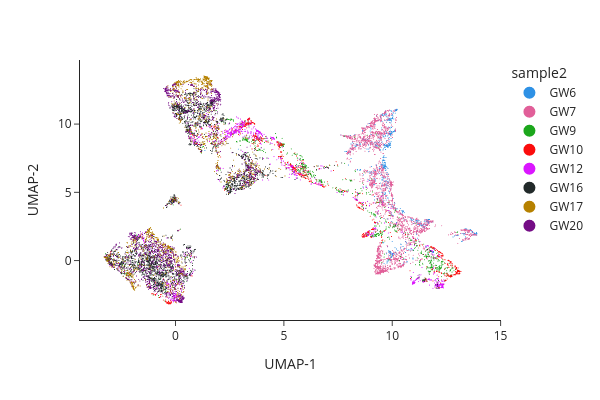

In [13]:
snap.tl.umap(adata, use_rep="X_spectral_mnn")
snap.pl.umap(adata, color="sample2", interactive=False)

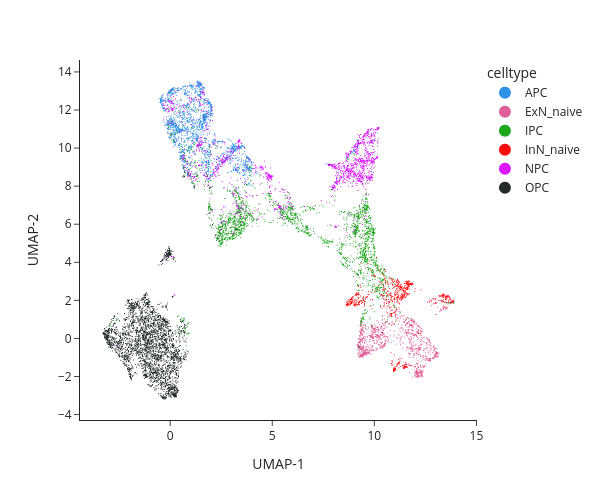

In [14]:
snap.pl.umap(adata, color="celltype", interactive=False, height=500)

In [15]:
adata.obs.to_csv('atac-meta.csv')

## Peak calling

In [16]:
%%time
snap.tl.macs3(adata, groupby='celltype', qvalue=0.01, blacklist='/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P2/SnapATAC2/hg38-blacklist.v2.bed')

2026-03-10 17:46:27 - INFO - Exporting fragments...
2026-03-10 17:47:32 - INFO - Calling peaks...
100%|██████████| 6/6 [05:51<00:00, 58.63s/it]


CPU times: user 3min 2s, sys: 2min, total: 5min 3s
Wall time: 7min 3s


In [17]:
adata

AnnData object with n_obs × n_vars = 11745 × 606219
    obs: 'sample2', 'barcode2', 'celltype'
    var: 'count', 'selected'
    uns: 'reference_sequences', 'AnnDataSet', 'spectral_eigenvalue', 'macs3'
    obsm: 'fragment_paired', 'X_spectral', 'X_umap', 'X_spectral_mnn'

In [18]:
adata.obsm['fragment_paired']

<11745x3088286401 sparse matrix of type '<class 'numpy.uint32'>'
	with 121959169 stored elements in Compressed Sparse Row format>

In [19]:
adata.write('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Snapatac2/IPC/ipc.h5ad')

... storing 'sample2' as categorical
... storing 'barcode2' as categorical
... storing 'celltype' as categorical


In [ ]:
adata = snap.read("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Snapatac2/IPC/ipc.h5ad", backed=None)
adata

In [20]:
%%time
peaks = snap.tl.merge_peaks(adata.uns['macs3'], snap.genome.hg38)
peaks.shape

CPU times: user 2.36 s, sys: 1.1 s, total: 3.45 s
Wall time: 1.59 s


(169879, 7)

In [21]:
chrom = peaks['Peaks']
chrom.to_pandas().to_csv('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Snapatac2/IPC/cCREs.csv', index=False)

In [22]:
%%time
peak_mat = snap.pp.make_peak_matrix(adata, use_rep=peaks['Peaks'])
peak_mat

CPU times: user 3min 57s, sys: 27.8 s, total: 4min 25s
Wall time: 6.61 s


AnnData object with n_obs × n_vars = 11745 × 169879
    obs: 'sample2', 'barcode2', 'celltype'

In [23]:
peak_mat.uns['reference_sequences'] = adata.uns['reference_sequences']
peak_mat.obsm['fragment_paired'] = adata.obsm['fragment_paired']

In [24]:
peak_mat.write('/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Snapatac2/IPC/peak_mat.h5ad')

In [ ]:
peak_mat = snap.read("/cluster2/huanglab/jiamao/Project/HumanSpinalCord/Work/P3/ATAC/Snapatac2/IPC/peak_mat.h5ad", backed=None)

In [25]:
%%time
marker_peaks = snap.tl.marker_regions(peak_mat, groupby='celltype', pvalue=0.05)

CPU times: user 5.85 s, sys: 200 ms, total: 6.05 s
Wall time: 6.07 s


In [26]:
marker_peaks

{'APC': Index(['chr1:1024958-1025459', 'chr1:1550521-1551022', 'chr1:1970533-1971034',
        'chr1:1989000-1989501', 'chr1:2086617-2087118', 'chr1:2124767-2125268',
        'chr1:2127265-2127766', 'chr1:2230196-2230697', 'chr1:2272220-2272721',
        'chr1:2322719-2323220',
        ...
        'chrX:154142798-154143299', 'chrX:154327017-154327518',
        'chrX:154355548-154356049', 'chrX:154734481-154734982',
        'chrX:154778133-154778634', 'chrX:155057307-155057808',
        'chrX:155612701-155613202', 'chrY:7834874-7835375',
        'chrY:7835511-7836012', 'chrY:13339909-13340410'],
       dtype='object', length=12041),
 'ExN_naive': Index(['chr1:869693-870194', 'chr1:905198-905699', 'chr1:911999-912500',
        'chr1:916464-916965', 'chr1:925433-925934', 'chr1:984088-984589',
        'chr1:1039220-1039721', 'chr1:1068517-1069018', 'chr1:1632039-1632540',
        'chr1:1881547-1882048',
        ...
        'chrX:154436607-154437108', 'chrX:154753442-154753943',
        'ch

2026-03-10 17:54:08 - WARNING - Input contains 61515 peaks, only 50000 peaks will be plotted.


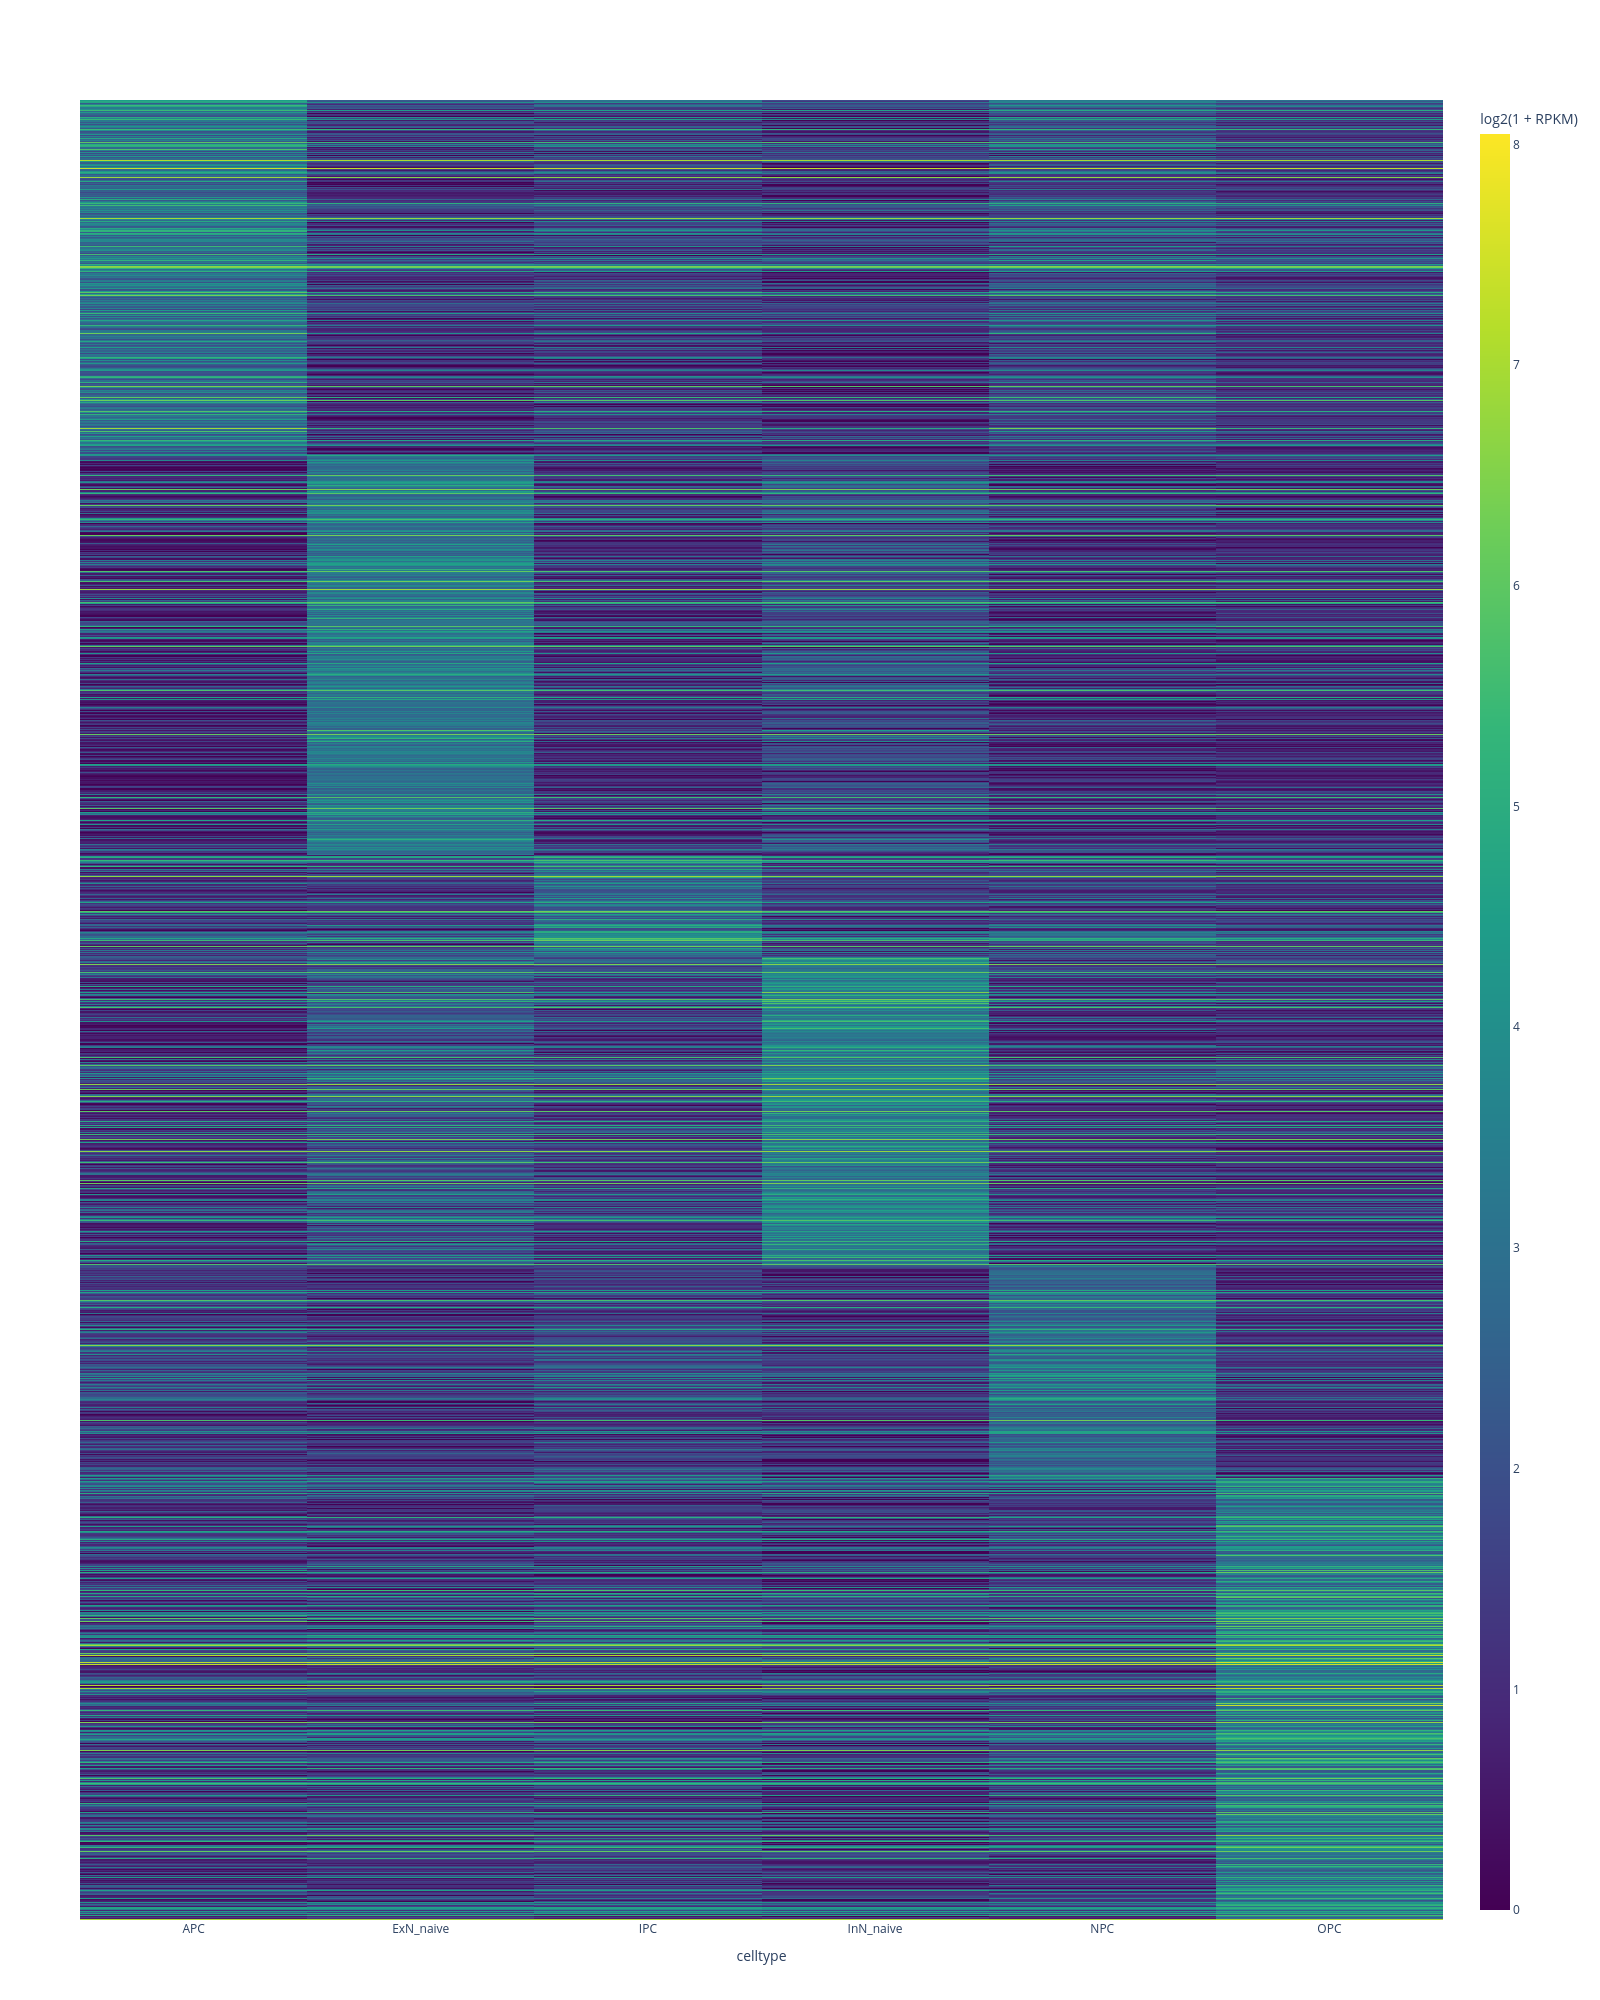

In [27]:
snap.pl.regions(peak_mat, 
                groupby='celltype', 
                peaks=marker_peaks, 
                width = 1600, 
                height = 2000,
                interactive=False)

In [28]:
data = []

# 遍历marker_peaks字典
for cell_type, peaks in marker_peaks.items():
    # 对于每个细胞类型的每个peak，添加到数据列表中
    for peak in peaks:
        data.append([peak, cell_type])

# 创建DataFrame
dar = pd.DataFrame(data, columns=['peak', 'cell_type'])

# 保存为CSV文件
dar.to_csv('ipc_marker_celltype_dar.csv', index=False)